# Adversarial black-box attacks

Мл задачи в ноутбуке:
* Ранжирование
* Классификация категориальных данных


## Импорт

In [1]:
from catboost import CatBoostRanker, CatBoostClassifier, Pool
from copy import deepcopy
import numpy as np
from sklearn.metrics import ndcg_score,accuracy_score
from catboost.datasets import msrank, adult

import os
import matplotlib.pyplot as plt
import bisect
import pandas as pd
import random, time
from collections import Counter

import torch
from torch import tensor as t

from foolbox.criteria import Misclassification as any_other_number
from foolbox.criteria import TargetedMisclassification as to_the_certain_number
from foolbox.attacks.gen_attack import GenAttack as fb_gen
import foolbox
from foolbox.distances import linf 

import importlib
import warnings
warnings.filterwarnings("ignore")

## Полезные функции

In [2]:
# Подсчет разных норм между состязательным и оригинальным объектами
def adv_distance(orig,adv):
    print('L2:',np.linalg.norm(orig-adv))
    print('L0:',np.sum((orig-adv)!=0))
    print(
        'L_inf (max):',
        np.round(np.max(np.abs(orig-adv)),4), 
        'Mean:',
        np.round(np.mean(np.abs(orig-adv)),4), 
        'Variance:',
        np.round(np.var(np.abs(orig-adv)),4))

In [3]:
# Поиск расстояния от объекта до самой близкой соседней точки в датасете
def first_neighbour(obj,data,feats):
    norm_coef = np.max(np.abs(data), axis=0)[feats]
    obj = obj[feats]/norm_coef
    data = data[:,feats]/norm_coef

    d = []
    for i in data:
        d.append(np.linalg.norm(i-obj))
    
    return min(d)

# Данные

## Msrank, ранжирование
Датасет [msrank](https://www.microsoft.com/en-us/research/project/mslr/) содержит набор групп объеков (без категориальных признаков) и целочисленные метки от 0 до 4 - релевантность объектов ранжированных внутри группы. Каждая группа соотвевует своему неизвестному веб-запросу, объекты внутри группы - это веб-страницы и признаки, основанные на содержании страницы и самого запроса.

In [4]:
# Скачивание датасета
train_df, test_df = msrank()

X_train = train_df.drop([0, 1], axis=1).values  # Признаки, (-1, 136)
y_train = train_df[0].values
queries_train = train_df[1].values              # id группы объектов

X_test = test_df.drop([0, 1], axis=1).values
y_test = test_df[0].values
queries_test = test_df[1].values


Достану первую группу тестовых объектов. Для дальнейшей работы с ней

In [5]:
a = [i for i,k in enumerate(queries_test) if k == queries_test[0]]
mr_first = X_test[a]
mr_y = y_test[a]

In [6]:
print('Количество признаков:',X_train.shape[1])
print('Количество групп:',np.unique(queries_train).shape[0])
print('Количество объектов:',X_train.shape[0])
print('Распределение классов в тренировочных данных:', *Counter(y_train).items())

rat4 = X_train.shape[1]/Counter(y_train)[4]

Количество признаков: 136
Количество групп: 6000
Количество объектов: 723412
Распределение классов в тренировочных данных: (2.0, 95082) (0.0, 377957) (1.0, 232569) (3.0, 12658) (4.0, 5146)


In [7]:
train_df.head(3)

,0,1,2,3,4,5,6,7,8,9,...,128,129,130,131,132,133,134,135,136,137
0,2.0,1.0,3.0,3.0,0.0,0.0,3.0,1.0,1.0,0.0,...,62.0,11089534.0,2.0,116.0,64034.0,13.0,3.0,0.0,0.0,0.0
1,0.0,1.0,3.0,0.0,3.0,0.0,3.0,1.0,0.0,1.0,...,44.0,5.0,30.0,23836.0,63634.0,2.0,4.0,0.0,0.0,0.0
2,0.0,1.0,3.0,0.0,3.0,0.0,3.0,1.0,0.0,1.0,...,59.0,5.0,8.0,213.0,48469.0,1.0,13.0,0.0,0.0,0.0


In [8]:
# Создание объектов Pool для тренировки CatBoost
mr_train = Pool(
    data=X_train,
    label=y_train,
    group_id=queries_train.astype('int')  # Указание групп
)

mr_test = Pool(
    data=X_test,
    label=y_test,
    group_id=queries_test.astype('int'),
)

mr_firstP = Pool(
    data=mr_first,
    label=mr_y,
    group_id=queries_test[:len(mr_first)].astype('int'),
)

In [9]:
# параметры обучения
default_parameters = {
    'iterations': 1000,
    'verbose': True,
    'random_seed': 0,
    'learning_rate': 0.05,
    'has_time':False,
    'od_wait': 200,
    #'task_type':'GPU'
}

def fit_model(loss_function, additional_params=None, iter = 1000):

    parameters = deepcopy(default_parameters)
    parameters['loss_function'] = loss_function
    parameters['train_dir'] = loss_function
    parameters['iterations'] = iter

    if additional_params is not None:
        parameters.update(additional_params)

    train_model = CatBoostRanker(**parameters)  # Модель ранжирования
    train_model.fit(mr_train, eval_set=mr_test, plot=True)

    return train_model
def norm(x,r=False):   # нормировка аутпута модели
    x-=np.min(x)
    x/=np.max(x)
    x*=4
    if r:
        return np.round(x)
    return x

In [10]:
mr_model = fit_model('PairLogit',iter = 10,)
print('Метрика ndcg на первой тестовой группе:',
      ndcg_score([norm(mr_model.predict(mr_first))],[mr_y]))

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.6905222	test: 0.6904826	best: 0.6904826 (0)	total: 13.6s	remaining: 2m 2s
1:	learn: 0.6875877	test: 0.6875486	best: 0.6875486 (1)	total: 25.6s	remaining: 1m 42s
2:	learn: 0.6853061	test: 0.6852879	best: 0.6852879 (2)	total: 36.7s	remaining: 1m 25s
3:	learn: 0.6832533	test: 0.6832380	best: 0.6832380 (3)	total: 48.2s	remaining: 1m 12s
4:	learn: 0.6816157	test: 0.6816831	best: 0.6816831 (4)	total: 1m	remaining: 1m
5:	learn: 0.6801543	test: 0.6802673	best: 0.6802673 (5)	total: 1m 11s	remaining: 48s
6:	learn: 0.6783954	test: 0.6785398	best: 0.6785398 (6)	total: 1m 24s	remaining: 36s
7:	learn: 0.6763866	test: 0.6766040	best: 0.6766040 (7)	total: 1m 36s	remaining: 24.1s
8:	learn: 0.6752152	test: 0.6754704	best: 0.6754704 (8)	total: 1m 51s	remaining: 12.4s
9:	learn: 0.6736764	test: 0.6739603	best: 0.6739603 (9)	total: 2m 3s	remaining: 0us

bestTest = 0.673960342
bestIteration = 9

Метрика ndcg на первой тестовой группе: 0.8781724566848544


In [11]:
# Получение списка индексов фич отсортированных по их важности
f = mr_model.get_feature_importance(type='PredictionValuesChange') 
feat_imp_list = []
for i in sorted(f)[::-1]:
    for k,j in enumerate(f):
        if j==i:
            feat_imp_list.append(k)
            break

In [12]:
sorted(f)[::-1]

[20.664303171942286,
 15.23528450335502,
 8.094072664936789,
 7.707760171318298,
 6.459790997880376,
 4.470945797213049,
 3.5220376176531047,
 3.1829474162119697,
 3.0063767337000415,
 2.2920339945565207,
 2.221359900339854,
 1.673903227939898,
 1.5257742635620044,
 1.5209828441755726,
 1.4740422965542346,
 1.3849464032215568,
 1.3243472991144223,
 1.1710039680255373,
 1.1370056792678955,
 0.9555540713552688,
 0.9023971027986091,
 0.8491748948255528,
 0.8248649996238133,
 0.7919721453743819,
 0.7703442543609356,
 0.7653145736955096,
 0.742320316086081,
 0.7087218605648664,
 0.6804650017396634,
 0.6556614925614669,
 0.5689985810471182,
 0.5154497213613621,
 0.44862934253097125,
 0.40965254605823587,
 0.3727000135136217,
 0.2919323777403338,
 0.28217352761276604,
 0.2426080445417762,
 0.13400937744047187,
 0.011118291050783732,
 0.007018513148042455,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 

## Adult, категориальные данные

In [188]:
train_a, test_a = adult()
train_a = train_a.dropna()
test_a = test_a.dropna()
print(train_a.size,test_a.size)

452430 225900


Из native-country оставлю только United-States

In [197]:
train_a = train_a[train_a['native-country'] == 'United-States']
test_a = test_a[test_a['native-country'] == 'United-States']

yad = train_a['income']
xad = train_a.drop(columns=['income','native-country','education']).copy()

yad1 = test_a['income']
xad1 = test_a.drop(columns=['income','native-country','education']).copy()

cat_features = ['workclass','marital-status','occupation','relationship','race','sex']

In [198]:
admodel = CatBoostClassifier(
    iterations=400,
    learning_rate = 0.1,
    depth = 5,
    l2_leaf_reg = None,
    cat_features=cat_features
    )
admodel.fit(xad,yad,verbose = 25)
pad1 = admodel.predict(xad1)
pad = admodel.predict(xad)
print('Train acuuracy:',accuracy_score(pad,yad))
print('test acuuracy:',accuracy_score(pad1,yad1))

0:	learn: 0.6011542	total: 90ms	remaining: 35.9s
25:	learn: 0.3199398	total: 1.41s	remaining: 20.3s
50:	learn: 0.3044808	total: 2.77s	remaining: 18.9s
75:	learn: 0.2952733	total: 4.12s	remaining: 17.6s
100:	learn: 0.2901607	total: 5.45s	remaining: 16.1s
125:	learn: 0.2840631	total: 6.87s	remaining: 14.9s
150:	learn: 0.2807447	total: 8.23s	remaining: 13.6s
175:	learn: 0.2777636	total: 9.57s	remaining: 12.2s
200:	learn: 0.2748318	total: 10.9s	remaining: 10.8s
225:	learn: 0.2726966	total: 12.3s	remaining: 9.46s
250:	learn: 0.2709315	total: 13.7s	remaining: 8.11s
275:	learn: 0.2692612	total: 15s	remaining: 6.74s
300:	learn: 0.2680525	total: 16.3s	remaining: 5.38s
325:	learn: 0.2668162	total: 17.7s	remaining: 4.02s
350:	learn: 0.2651989	total: 19.1s	remaining: 2.66s
375:	learn: 0.2639912	total: 20.5s	remaining: 1.31s
399:	learn: 0.2627169	total: 21.8s	remaining: 0us
Train acuuracy: 0.8795811518324608
test acuuracy: 0.8672033652451407


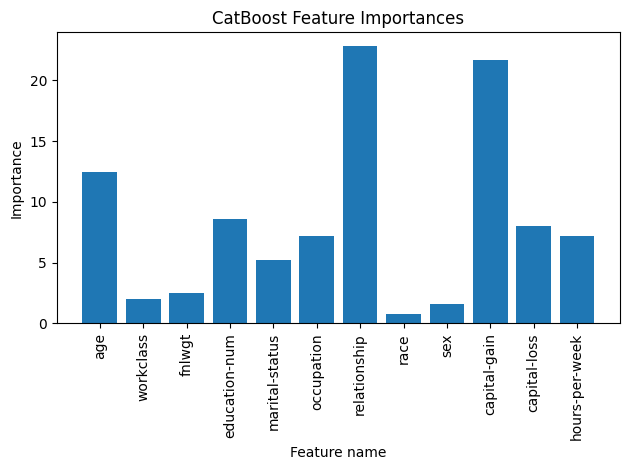

In [199]:
feature_importances = admodel.get_feature_importance()
feature_names = list(xad.columns)

plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel("Feature name")
plt.ylabel("Importance")
plt.title("CatBoost Feature Importances")
plt.xticks(np.arange(len(feature_importances)), feature_names, rotation=90)
plt.tight_layout()

plt.show()

### Логика атаки

Evasion атака позволит найти такие малые изменения объекта класса >50K, чтобы модель классифицировало его, как <50К. 
Датасет adult представляет задачу предсказания уровня дохода человека, по некоторым характеристикам. 
Можно представить, что мотивация злоумышленника - это заставить модель классифицировать заработок человека как маленький, с целью получения каких либо льгот, например, налоговых.

In [200]:
d = {}
for i in cat_features:
    d[i] = [Counter(xad[yad == ">50K"][i]),Counter(xad[i])]#set(xad[i])

feat_association = {}

for i in d.keys():
    print(i, d[i])

workclass [Counter({'Private': 4541, 'Self-emp-not-inc': 659, 'Local-gov': 575, 'Self-emp-inc': 558, 'Federal-gov': 336, 'State-gov': 326}), Counter({'Private': 20135, 'Self-emp-not-inc': 2313, 'Local-gov': 1956, 'State-gov': 1210, 'Self-emp-inc': 991, 'Federal-gov': 886, 'Without-pay': 13})]
marital-status [Counter({'Married-civ-spouse': 5959, 'Never-married': 441, 'Divorced': 429, 'Widowed': 71, 'Separated': 60, 'Married-spouse-absent': 25, 'Married-AF-spouse': 10}), Counter({'Married-civ-spouse': 12798, 'Never-married': 8876, 'Divorced': 3993, 'Separated': 825, 'Widowed': 758, 'Married-spouse-absent': 233, 'Married-AF-spouse': 21})]
occupation [Counter({'Exec-managerial': 1818, 'Prof-specialty': 1650, 'Sales': 928, 'Craft-repair': 860, 'Adm-clerical': 458, 'Transport-moving': 305, 'Tech-support': 257, 'Machine-op-inspct': 224, 'Protective-serv': 203, 'Farming-fishing': 111, 'Other-service': 106, 'Handlers-cleaners': 73, 'Armed-Forces': 1, 'Priv-house-serv': 1}), Counter({'Exec-manag

In [201]:
perm_cat = ['age','race','sex','occupation','fnlwgt']
rand_cat = ['relationship','marital-status']
degree_cat = ['workclass']
numeric = ['capital-gain','capital-loss','hours-per-week','education-num']

Пусть для злоумышленника: 
1. Не возможно соврать про свой пол, цвет кожи и сферу деятельности 
2. Возможно соврать про характеристики из списков numeric, но не выходя за некоторые рамки (например, не больше чем на 10%)
3. Ему все равно, на что менять признаки из списка rand_cat вместо реальных, но желательно как можно больше признаков оставить правдивыми.
4. Можно предположить, что для злоумышленника признак workclass имеет разную сложность подделки каждого статуса, и поэтому имеет смысл отсортировать возможные значения признаков и учитывать разницу в алгоритме атаки.

ChatGPT: "Вот сортировка workclass по уровню серьёзности (от наименее проверяемого к наиболее серьёзному и официальному):"

1. Self-emp-not-inc (самозанятый, не зарегистрированный)
2. Private (частный сектор)
3. Self-emp-inc (самозанятый, зарегистрированный как ИП или компания)
4. Local-gov (местные органы власти)
5. State-gov (государственные органы на уровне штата/региона)
6. Federal-gov

In [ ]:
# Словарь для признака workclass и его значения 
degree_dict = {
    'workclass': ['Self-emp-not-inc', 'Private', 'Self-emp-inc', 'Local-gov','State-gov','Federal-gov'],
    }

# Словарь признаков, для которых не важно, на что заменять оригинальное значение
rand_dict = {}
for i in rand_cat:
    rand_dict[i] = list(set(xad[i]))
# Исключение Own-child(является ребенком) и Wife, так как буду рассматривать пример для взрослого мужчины
rand_dict['relationship'].remove('Own-child')
rand_dict['relationship'].remove('Wife')

# Создание списка из фич, которые будут атаковаться
feats = list(xad.columns)
feats = [i for i in feats if i not in perm_cat]

# Создание словаря для нормировки фич в интервал 0-1
norm_coef = {}
for i in numeric:
    norm_coef[i] = np.max(xad[i])
for i in rand_cat:
    norm_coef[i] = len(rand_dict[i])-1
for i in degree_cat:
    norm_coef[i] = len(degree_dict[i])-1
norm_coef

{'capital-gain': 99999.0,
 'capital-loss': 4356.0,
 'hours-per-week': 99.0,
 'education-num': 16.0,
 'relationship': 3,
 'marital-status': 6,
 'workclass': 5}

In [ ]:
# Функция преобразования категориальных данных в нампай
def cat2num(cat_obj,col = xad.columns,norm_coef = None):

    if not norm_coef:
        norm_coef = {f:1 for f in feats}

    num_obj = []
    for i in col:
        if i in rand_cat:
            num_obj.append(rand_dict[i].index(cat_obj[i]))
        elif i in numeric:
            num_obj.append(cat_obj[i])
        elif i in degree_cat:
            num_obj.append(degree_dict[i].index(cat_obj[i]))
        else:
            continue
        num_obj[-1]/=norm_coef[i]


    return np.array(num_obj)

In [ ]:
# Преобразование нампай в категориальный датафрейм
def num2cat(num_obj,orig_cat,col = xad.columns,norm_coef = None):
    cat_obj = {}
    if not norm_coef:
        norm_coef = {f:1 for f in feats}
    for k,i in enumerate(col):
        #print(len(num_obj),i,k)
        if i in numeric:
            cat_obj[i] = num_obj[k]*norm_coef[i]
            if  i == 'education-num' or i=='hours-per-week':
                cat_obj[i] = np.round(cat_obj[i])
        elif i in rand_cat:
            cat_obj[i] = rand_dict[i][int(num_obj[k]*norm_coef[i])]
        elif i in perm_cat:
            cat_obj[i] = orig_cat[i]
        elif i in degree_cat:
            cat_obj[i] = degree_dict[i][int(num_obj[k]*norm_coef[i])] 
    return pd.DataFrame([cat_obj])
    

In [257]:
from foolbox.attacks import gen_attack
importlib.reload(foolbox)
importlib.reload(gen_attack)
from foolbox.attacks.gen_attack import GenAttack as fb_gen

# Adversarial атаки 

## Атака на категориальный датасет

### Обертка

In [ ]:
class CatWrapper():
    def __init__(
            self, 
            model, # Модель
            feats, # Фичи для атаки
            orig,  # Оригинальный атакуемый объект
            norm_coef # Словарь с нормировкой
            ):
        self.feats = feats
        self.norm_coef = norm_coef
        self.orig = orig
        self.model = model
        self.queries = 0

    def __call__(self, obj):
        obj = obj.copy().reshape(1,-1)

        a = pd.DataFrame([self.orig.to_dict()]*len(obj))
        for i in range(len(a)):
            obj_i = obj[i]

            for j in self.feats:
                a.at[i,j] = num2cat(obj_i,orig_cat=self.orig,col = feats, norm_coef = self.norm_coef)[j][0]
        
        #print(a.iloc[0])
        a = self.model.predict_proba(a)


        return np.array(a)

### Атака adult 

Я могу подавать в обертку фичи доступные для атаки (feats) и жадным способом проатаковать разные категории фич разными атаками. Таким образом можно разбить атаку на этапы: 
1. Все фичи можно атаковать алгоритмом максимизирующим ошибку модели так, чтобы каждый отдельный признак не превышал заданный предел (L_inf норма);
2. К моменту, когда модель начнет ошибаться на полученном возмущении, можно применять алгоритмы, минимизирующие возмущение, сохраняя ошибочный ответ модели. 
3. К возмущению фич degree_cat можно применить алгоритм минимизирующий L_2 норму, для фич rand_cat применить минимизацию по L_0 норме (т.е. минимизировать количество измененных признаков, а не их значение) 

In [303]:
obj = xad1.loc[3] # Объект, классифицирующийся как >50K
print('Prediction:',admodel.predict(obj), 'True label:',yad1.loc[3])
print('original object:')
pd.DataFrame([obj])

Prediction: >50K True label: >50K
original object:


,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week
3,44.0,Private,160323.0,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0


In [304]:
norm_coef

{'capital-gain': 99999.0,
 'capital-loss': 4356.0,
 'hours-per-week': 99.0,
 'education-num': 16.0,
 'relationship': 3,
 'marital-status': 6,
 'workclass': 5}

Коэффициенты для признаков 'relationship','marital-status', 'workclass' - это количество возможных вариантов значений фич минус один, т.е. алгоритм атаки принимает на вход нормированный индекс фичи.

In [305]:
np_obj = np.array(cat2num(obj,norm_coef= norm_coef)).reshape((1,-1))

In [306]:
wmodel = CatWrapper(
    model = admodel,
    feats= rand_cat+numeric+degree_cat,
    orig = obj,
    norm_coef=norm_coef    
)
wmodel(np_obj) # Предикт модели

array([[0.02736142, 0.97263858]])

In [307]:
# Атака, максимизирующая лосс модели, основанная на генетическом алгоритме 
gen_attack = fb_gen(steps=1000,)
fb_model = foolbox.NumPyModel(wmodel,bounds = (0,1)) # Обертка над оберткой
_,x_adv,s = gen_attack(fb_model,np_obj,criterion=to_the_certain_number(np.array([0])),epsilons=0.01)

In [308]:
a = obj.copy()
for j in feats:
    a.at[j] = num2cat(x_adv[0],orig_cat=obj,col = feats, norm_coef = norm_coef)[j][0]

In [309]:
pd.DataFrame([obj]) # Вид оригинального объекта

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week
3,44.0,Private,160323.0,10.0,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688.0,0.0,40.0


In [310]:
pd.DataFrame([a]) # Вид состязательного объекта

,age,workclass,fnlwgt,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week
3,44.0,Self-emp-not-inc,160323.0,10.0,Married-civ-spouse,Machine-op-inspct,Not-in-family,Black,Male,6688.01,43.56,40.0


In [311]:
# Предсказания модели на оригинальном и состязательном примере
admodel.predict(obj), admodel.predict(a)

('>50K', '<=50K')

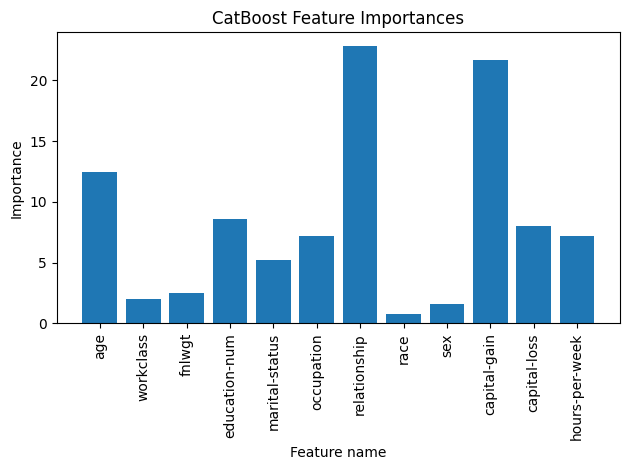

In [312]:
feature_importances = admodel.get_feature_importance()
feature_names = list(xad.columns)

plt.bar(range(len(feature_importances)), feature_importances)
plt.xlabel("Feature name")
plt.ylabel("Importance")
plt.title("CatBoost Feature Importances")
plt.xticks(np.arange(len(feature_importances)), feature_names, rotation=90)
plt.tight_layout()

plt.show()

Выше приведена статистика значимости каждой фичи для модели, полученная методом модели CatBoost. Наиболее значимы relationship и capital-gain. Для получения состязательного примера атака как раз дала изменение этих двух признаков

## Атака на ранжирование

### Обертка

In [145]:
class CatBoostWrapper:
    def __init__(
            self, 
            model,
            feats,    # Индексы фич доступных для атаки
            orig,
            norm_coef, # Все признаки перед атакой нормируются в интервал 0-1
            rating = []
            ):
        
        self.feats = feats
        self.norm_coef = np.array(norm_coef)
        self.orig = orig
        self.model = model
        self.queries = 0
        self.true_lab = 0
        self.history = []
        self.thr = 0.1
        self.rating = rating
        self.only_rank_info = False   # Алгоритм атаки получает только информацию о позиции объекта в рейтинге

    def __call__(self, obj):

        a = np.array([self.orig.copy()]*len(obj.numpy()))
        a[:,self.feats] = np.multiply(self.norm_coef,obj.clone().numpy())
        a = self.model.predict(a)
        if self.only_rank_info:
            b = []
            for i in a:
                b.append(
                    bisect.bisect_left(self.rating,i) # поиск позиции объекта в рейтинге
                    ) 
            a = np.array(b)/len(self.rating)
            print('Позиция в рейтинге:',a*len(self.rating))
        a = -a
        return t(np.vstack([a,np.ones(a.shape)*(-self.thr)]).T)
    


### Атака с использованием только информации о положении объекта в выдаче

In [146]:
p = mr_model.predict(mr_first)
obj = mr_first[2].copy()
f_count = 20
feats = feat_imp_list[:f_count]
norm_coef = np.max(np.abs(X_train), axis=0)[feats]

In [147]:
wmodel = CatBoostWrapper(mr_model,
                         feats=feats,
                         orig = obj,
                         norm_coef = norm_coef,
                         rating = sorted(p))
wmodel.only_rank_info = True
wmodel.thr = len(p)

mr_model.predict(obj)

-0.034956479652122834

In [148]:
from ares.utils.registry import registry

eps = 0.0801
attacker_cls = registry.get_attack('spsa')
attacker = attacker_cls(wmodel,device='cpu',
                         target=False,
                         eps=eps,
                         sample_per_draw = 10,
                         norm = np.inf,
                         learning_rate=0.01,
                         delta = 0.01,
                         nb_iter = 1000
                         
                         )
print('OK')
adv = attacker(t([obj.copy()[feats]/norm_coef]),t([0]))
print(wmodel(adv))
help_adv = obj.copy()
help_adv[feat_imp_list[:f_count]] = adv.numpy()*norm_coef
adv = help_adv
print(mr_model.predict(adv))

OK
Позиция в рейтинге: [36.]
Позиция в рейтинге: [ 43. 138. 133.  55. 133. 133. 133. 138.  52. 133.]
Позиция в рейтинге: [137.  49. 130. 133.  47.  53. 118.  45. 133.  50.]
Позиция в рейтинге: [104.]
Позиция в рейтинге: [104.]
Позиция в рейтинге: [133.  44. 138. 138. 133. 133.  50. 123.  38. 138.]
Позиция в рейтинге: [ 38. 138.  46.  44. 109. 130. 137. 133. 138.  52.]
Позиция в рейтинге: [138.]
Позиция в рейтинге: [138.]
Позиция в рейтинге: [138.  60.  45. 137. 137. 133. 138.  43.  38. 131.]
Позиция в рейтинге: [ 34. 133. 133.  52.  44. 131.  50. 138. 138. 133.]
Позиция в рейтинге: [138.]
Позиция в рейтинге: [138.]
Позиция в рейтинге: [ 54. 137. 138.  43. 133. 138. 135.  58. 138.  52.]
Позиция в рейтинге: [133.  44.  46. 138.  49.  52.  64. 133.  34. 133.]
Позиция в рейтинге: [138.]
Позиция в рейтинге: [138.]
Позиция в рейтинге: [ 49.  50. 138. 138.  54. 133.  50. 138.  54. 138.]
Позиция в рейтинге: [138. 133.  45.  46. 133.  49. 133.  50. 138.  47.]
Позиция в рейтинге: [138.]
Позиция 

In [149]:
adv_distance(adv[feat_imp_list[:f_count]]/norm_coef,obj[feat_imp_list[:f_count]]/norm_coef)
print(f'* Максимальное изменение признака: {np.round(100*eps,2)}%')

L2: 0.2823111640528916
L0: 19
L_inf (max): 0.0801 Mean: 0.0572 Variance: 0.0007
* Максимальное изменение признака: 8.01%


In [150]:
print('Расстояние до ближайшего объекта датасета (L2):\n', 
      first_neighbour(obj,X_train,feat_imp_list[:f_count]))
print('Расстояние от состязательного примера до ближайшего объекта датасета (L2):\n', 
      first_neighbour(adv,X_train,feat_imp_list[:f_count]))
print('Расстояние от состязательного примера до ближайшего объекта ранжируемой группы (L2):\n', 
      first_neighbour(adv,mr_first,feat_imp_list[:f_count]))

Расстояние до ближайшего объекта датасета (L2):
 0.008174817718593708
Расстояние от состязательного примера до ближайшего объекта датасета (L2):
 0.23795803034746676
Расстояние от состязательного примера до ближайшего объекта ранжируемой группы (L2):
 1192.3941258863492


## Эксперимент по написанию своей атаки из статьи (OPT attack)

### Теория

В статье [Query-Efficient Hard-label Black-box Attack:
An Optimization-based Approach
](https://arxiv.org/pdf/1807.04457) задача поиска состязательных примеров строится, как задача поиска такого направления возмущения teta/|teta|, что модуль этого возмущения будет минимальным.

Статья предлагает метод поиска состязательных примеров для black box hard-label (известен только сам результат классификации, без вероятностей) атак на модели классификации нейронных сетей и по совместительству данный метод работает для атак на модели градиентного бустинга

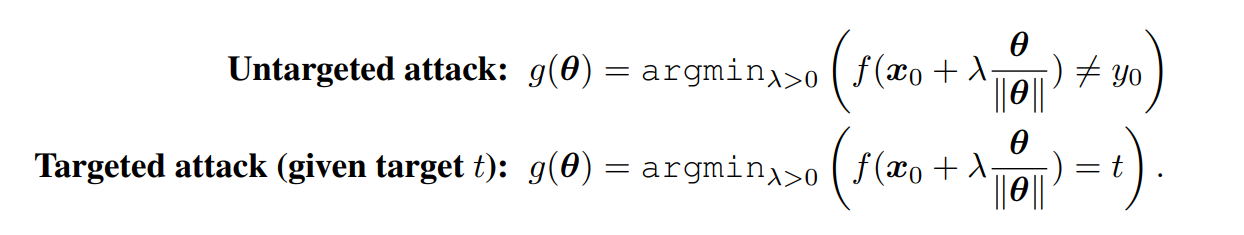

На картинке f - это модель, x_0 оригинальный объект, lambda - модуль возмущения, x_0+lambda*teta/|teta| - состязательный пример, g(teta) - минимизируемая функция, которая возвращает модуль возмущения

Авторы утверждают, что, как правило, функция g(teta) будет непрерывной, и  приводят примеры g(teta) для функций принятия решений с двумерным инпутом

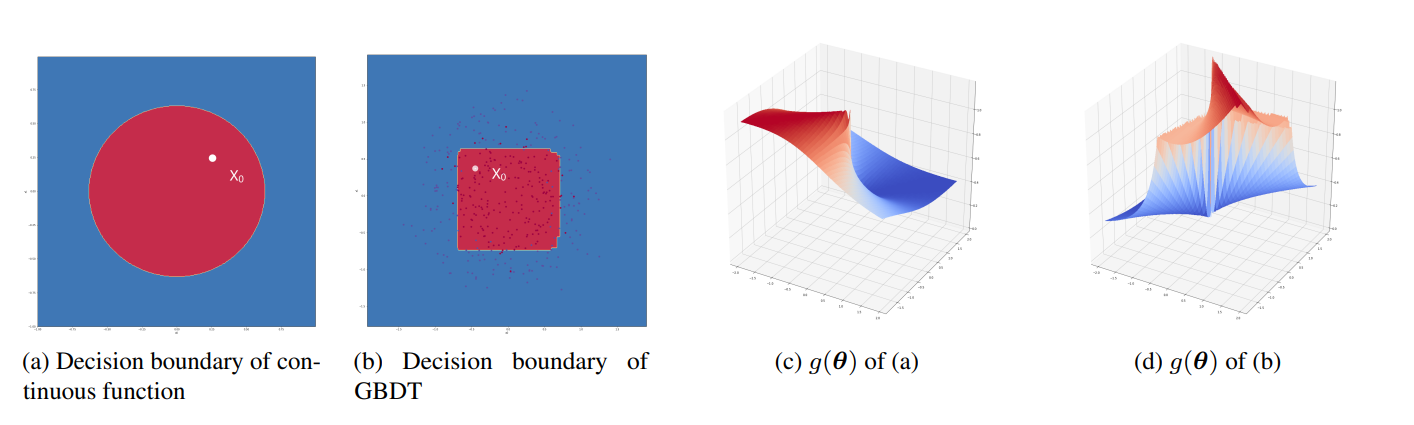

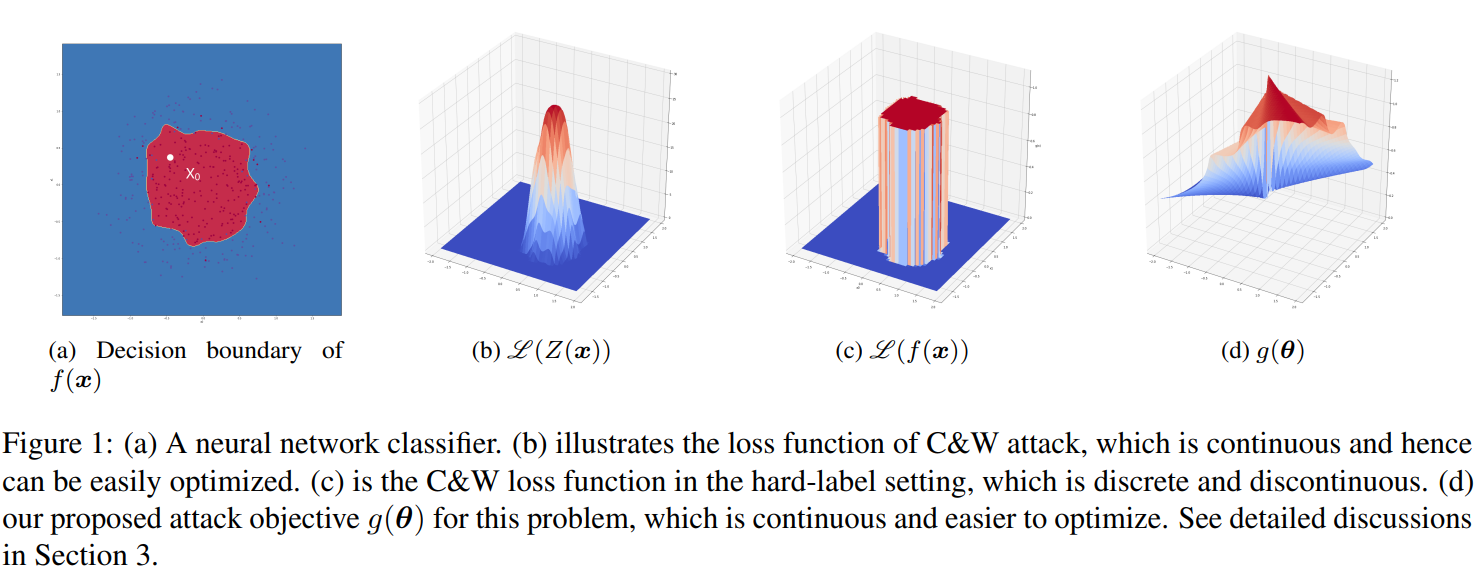

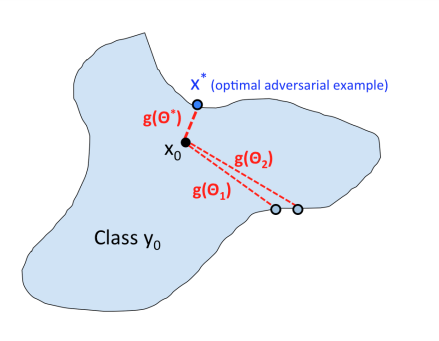

Для поиска минимума предлагается использовать оптимизацию нулевого порядка и градиентный спуск, в котором градиент оценивается образом на картинке ниже.

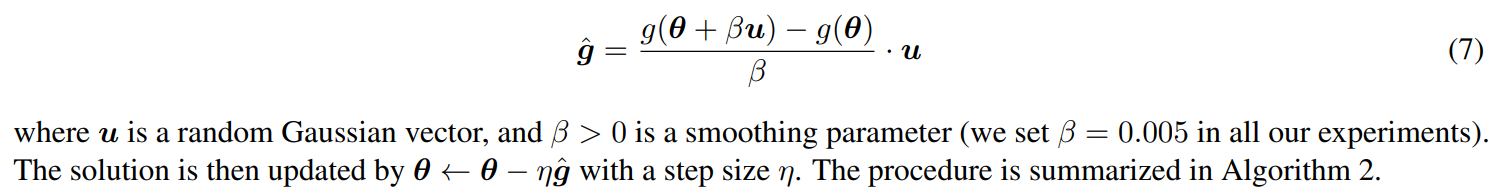

При этом значение функции g(teta), можно найти только приблеженно и для этого используется алгоритм бинарного поиска

### Функция атаки

Функция ниже принимает направление возмущения и вычисляет необходимый модуль для ошибочного предикта

In [151]:
# Вычисление функции g(teta) согласно статье
def compute_g(orig,                   # Оригинальный объект
              model,                  # Модель
              direction,              # Teta
              init_v=0.1,             # Инициализация модуля возмущения для бинарного поиска
              eps_acc= 0.001,        # Точность поиска модуля
              alpha = 0.05,           # Параметр инициализации границ бинарного поиска
              perturb_limit = 10**2,  # Ограничение на модуль возмущения
              perturb_func = sum,
              r_q = True,
              attack_goal = lambda x: x>0
    ):
  

  direction /=np.linalg.norm(direction)  # Teta/|teta|
  p = attack_goal(model.predict(perturb_func(orig, direction*init_v)))
  model_q = 1

  if p == False:
    l = init_v
    r = (1+alpha)*init_v
    while p == False:
      r = (1+alpha)*r
      p = attack_goal(model.predict(perturb_func(orig, direction*r)))
      model_q+=1

      if r>perturb_limit:
        if r_q:
          return r,model_q
        else: 
          return r

  else:
    r = init_v
    l = (1-alpha)*init_v
    model_q+=1
    while attack_goal(model.predict(perturb_func(orig, direction*l))) == True:
      model_q+=1
      l = (1-alpha)*l

  while r-l >eps_acc:
    v = r/2+l/2

    model_q+=1
    if attack_goal(model.predict(perturb_func(orig, direction*v))) == False:
      l = v
    else:
      r = v
  if r_q:
    return r,model_q
  return r

In [152]:
# Функция для изменения размерности вектора возмущения
# Возмущение размерностью len(feat_imp_list) становится той же размерностью, что и оригинальный объект

def perturb_resoluting(p,     # Вектор возмущения
                       feat,  # Индексы фич для возмущения
                       s      # Размерность оригинального объекта
    ):
    x = np.zeros((s))
    k = 0
    for i in p:
        x[feat[k]] = i
        k+=1
    return x

def perturb_irresoluting(p,feat):
    x = np.zeros(len(feat))
    k = 0
    for i in feat:
        x[k] = p[i]
        k+=1
    return x

Функция атаки

Принимает несколько параметров: 

* Оригинальный объект

* Модель с методом predict()

* Список фич для возмущения (по умолчанию все фичи)

* Параметры оптимизации beta/nu_step

* Количество попыток генераций начального возмущения, которое алгоритм будет оптимизировать

* Функция добавления возмущения к оригинальному объекту (по умолчанию perturb_func = sum(Original object, Perturb vector))

* Функция успешности атаки (attack_goal( Advesarial_Prediction ) = Advesarial_Prediction > 0 )



In [153]:
def chengs_advesarial(orig,              # Невозмущенный оригинальный объект
                      model,
                      fl = None,            # Список важных фич
                      beta=0.001,        # Сглаживающий параметр, чем ниже, тем меньше скачков в поиске возмущения?
                      nu_step = 5e-4,    # Шаг градиентного спуска
                      iter = 500,        # Количество шагов
                      verbose = False,
                      attempts = 5000,    # Количество случайных инициализаций
                      perturb_limit = 10**2,  # Ограничение на модуль возмущения
                      perturb_func = sum,
                      attack_goal = lambda x: float(x)>0,
                      sup_vec = [],
                      noise_coef = 1,
                      return_init_perturb = False
                      ):
  
  inner_compute_g = lambda direction, eps_acc = 1e-4, alpha = 0.05,r_q=True: compute_g(direction=direction,
                                                                              orig = orig,
                                                                              model = model,
                                                                              perturb_func = perturb_func,
                                                                              eps_acc = eps_acc,
                                                                              alpha = alpha,
                                                                              attack_goal = attack_goal,
                                                                              perturb_limit=perturb_limit,
                                                                              r_q = r_q
                                                                    )

  init_dir = sup_vec.copy()
  
  if not fl:
    fl = list(range(len(orig)))
    
  if len(init_dir) == 0: 
    init_dir = [0]*len(fl)
  else:
    init_dir = np.array(init_dir.copy())-np.array(orig)
    init_dir = perturb_irresoluting(init_dir.copy(),fl)
  def print_if_verbose(*s):
    if verbose:
      print(*s)
  h = []
  q = 0
  # Сначала генерируется большое количество направлений
  # Среди которых выбирается возмущение с наименьшим модулем

  random_search_t = time.time()
  dirs = [np.random.normal(0, 1, len(fl)) for _ in range(attempts)]
  dirs = [dir/np.linalg.norm(dir)*noise_coef+init_dir for dir in dirs]

  g_dirs = [inner_compute_g(perturb_resoluting(dir,fl,s = len(orig)),eps_acc=0.1,alpha = 0.1,r_q = False) for dir in dirs]
  best_g = perturb_limit
  best_dir_id = 0
  for i in range(len(g_dirs)):
    if g_dirs[i]< best_g:
        best_g = g_dirs[i]
        best_dir_id = i

  init_dir = dirs[best_dir_id]
  best_dir = init_dir.copy()
  dir = init_dir.copy()
  print_if_verbose('Время генерации случайных примеров:',time.time()-random_search_t)
  print_if_verbose('Init_perturb:', best_g)

  optimization_t = time.time()

  for i in range(iter):
    if i!=0:
      print_if_verbose('OK',i)

    u = np.random.normal(0, 1, dir.shape)
    g1,q0 = inner_compute_g(perturb_resoluting(dir,fl,s = len(orig)))
    q+=q0
    g2,q0 = inner_compute_g(perturb_resoluting(dir+u*beta,fl, len(orig)))
    q+=q0
    print('g1, g2:',g1,g2)
    g = (g2-g1)*u/beta
    dir -= nu_step*g
    v,q0 = inner_compute_g(perturb_resoluting(dir,fl,len(orig)))
    q+=q0

    if g1 >= perturb_limit or g2 >= perturb_limit:
      print_if_verbose('Неудачная инициализация направления')
      return -1,-1, [],q
    if v >= perturb_limit:
      print_if_verbose('No adv with such direction')

    print_if_verbose(' Orig Prediction:', model.predict(orig), '\n',
                     'Adv Prediction :', model.predict(perturb_func(orig,v*perturb_resoluting(dir/np.linalg.norm(dir),fl,len(orig)))), '\n',
                     'Perturb norm:',v,
    )
    h.append(v)
    if v<best_g and attack_goal(model.predict(perturb_func(orig,v*perturb_resoluting(dir/np.linalg.norm(dir),fl,len(orig))))):
      best_g = v
      best_dir = dir.copy()
      
  
  print_if_verbose('Время работа оптимизационного алгоритма:',time.time()-optimization_t)
  print_if_verbose('Количество запросов к модели:',q)

  if return_init_perturb:
    v_of_init_dir,q0 = inner_compute_g(perturb_resoluting(init_dir,fl,len(orig)))
    return [perturb_func(orig, perturb_resoluting(best_g*best_dir/np.linalg.norm(best_dir),fl,len(orig))),
            perturb_func(orig, perturb_resoluting(v_of_init_dir*init_dir/np.linalg.norm(init_dir),fl,len(orig)))
           ], best_g, h,q
  else:
    return perturb_func(orig, perturb_resoluting(best_g*best_dir/np.linalg.norm(best_dir),fl,len(orig))), best_g, h,q


### Прочие вспомогательные функции

Получившиеся состязательные примеры должны иметь одинаковые типы данных признаков и соответвовать другим ограничениям, которые могу иметь реальные признаки. Такое ограничение можно учесть в perturb_func.

In [154]:
# Завожу список с типами данных каждого признака
features_type = []
# И ещё список с максимальным и минимальным значениями признака
f_range  = []

# Проход по всем фичам
for i in range(X_test.shape[1]):
    f_range.append([np.min(X_test[:,i]),np.max(X_test[:,i])])
    if all(X_test[:,i].astype('int') ==X_test[:,i]):
        if np.max(X_test[:,i]) == 1. and np.min(X_test[:,i]) == 0.:
            features_type.append('boolean')
        else:
            features_type.append('int')
    else:
        features_type.append('float')

In [155]:
# Функция подгонки состязательного примера под критерии
def type_norm(perturb,features_type = features_type, f_range = f_range):
    for i in range(len(features_type)):
        if features_type[i]=='int':
            perturb[i] = np.round(perturb[i])
        elif features_type[i] =='boolean':
            perturb[i] = float(perturb[i]>=0.5)

        if perturb[i]<f_range[i][0]:
            perturb[i] = f_range[i][0]
        elif perturb[i]>f_range[i][1]:
            perturb[i] = f_range[i][1]
    return perturb

### Процесс подбора параметров обучения

Для успешного и стабильного поиска состязательных примеров для каждой нужно подобрать параметр мглаживания beta, nu_step, количество итераций, начальное направление возмущения.

Целью атаки attack_goal будет условие, что предсказание выше определенного порога thr

Функция возмущения perturb_func - это сумма объекта и вектора возмущения обработанная функцией type_norm(), которая учитывает ограничения на фичи

In [156]:
p0 = mr_model.predict(mr_first)
thr = sorted(p0)[int(len(p0)*0.8)]  

print('Порог значения предсказания релевантного объекта:',np.round(thr,4))

x = mr_first[2]
p0 = mr_model.predict(x)

print('Предикт оригинального исследуемого примера:      ',np.round(p0,4))

Порог значения предсказания релевантного объекта: 0.1481
Предикт оригинального исследуемого примера:       -0.035


* feat_imp_list - список индексов фич, отсортированный по их важности

In [157]:
adv = -1
f_count = 20
while type(adv) ==int:

    adv, d, h,_ = chengs_advesarial(x,
                                mr_model,
                                fl = feat_imp_list[:f_count],   # Беру несколько первых наиболее важных фич
                                iter = 500,
                                beta =0.002,
                                nu_step = 0.0004,
                                verbose = True,
                                attempts = 500,
                                perturb_func = lambda a,b: type_norm(a+b),
                                attack_goal= lambda x: x> thr,
                                return_init_perturb = True,
                                
                )

KeyboardInterrupt: 

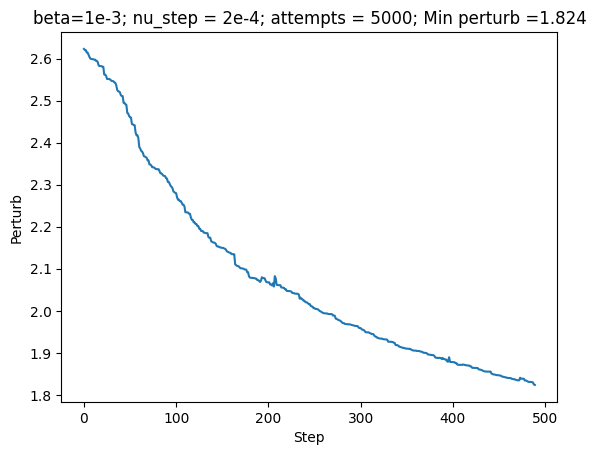

In [ ]:
plt.plot(h[10:])
#plt.plot(exp_fit)
#plt.axhline(min(h),ls = '--')
plt.xlabel('Step')
plt.ylabel('Perturb')
plt.title(f"beta=1e-3; nu_step = 2e-4; attempts = 5000; Min perturb ="+str(np.round(min(h),3)))
plt.show()

Графики с другими параметрами оптимизации

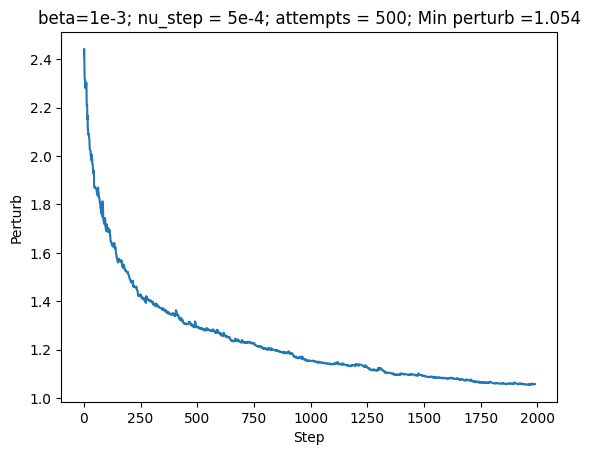

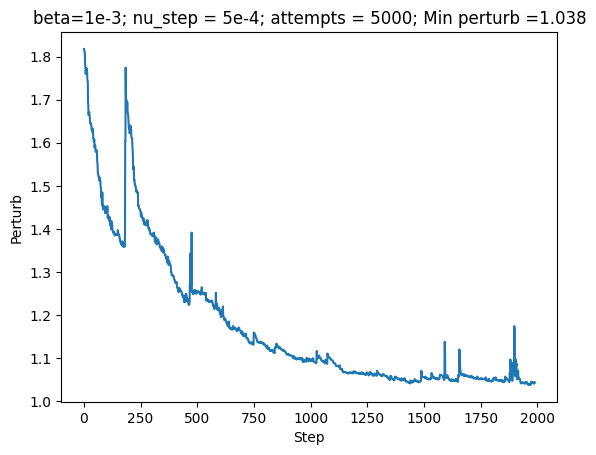

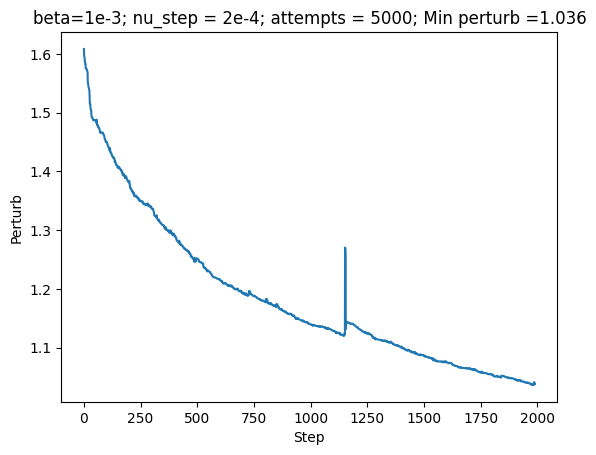

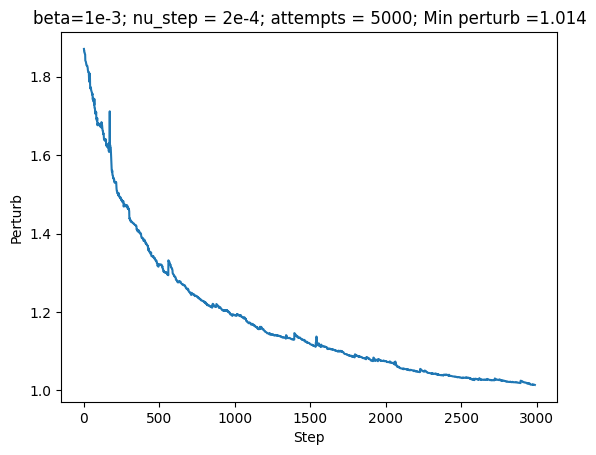

Из экспериментов поиска состязательных примеров можно сделать вывод, что, во первых, с каждым шагом изменение модуля возмущения экспоненциально затухет и постепенно выходит в константу. Во вторых, чем меньше шаг и чем меньше beta, тем более сглажен график. В третьих, на втором графике параметр attempts меньше, а итоговый модуль возмущение больше, что свидетильствует о том, что лучшая начальная инициализация даст наименьшее конечное возмущение

Можно предположить, что если взять наилучшую инициализацию направления возмущения и проделать 2000 шагов оптимизации, то получится наименьшее возмущение, с которым можно обмануть модель. 

### Оценка схожести состязательного примера и оригинального c нормированными признаками

In [ ]:
adv_distance(adv[0][feat_imp_list[:f_count]]/norm_coef,x[feat_imp_list[:f_count]]/norm_coef)

L2: 0.4834568713846446
L0: 17
L_inf (max): 0.4474 Mean: 0.0337 Variance: 0.0106


In [ ]:
print('Расстояние до ближайшего объекта датасета:', 
      first_neighbour(x,X_train,feat_imp_list[:f_count]))
print('Расстояние от состязательного примера до ближайшего объекта датасета:', 
      first_neighbour(adv[0],X_train,feat_imp_list[:f_count]))

Расстояние до ближайшего объекта датасета: 0.008174817718593708
Расстояние от состязательного примера до ближайшего объекта датасета: 0.25637772452623075


In [ ]:
sorted(np.abs(adv[0]-x)[feat_imp_list[:f_count]]/norm_coef)[::-1][:5]

[0.44738593073722477,
 0.1800713066894035,
 0.03347445406751073,
 0.0038276847644835325,
 0.0028404117832175513]

In [ ]:
np.array(feat_imp_list[:f_count])[np.argsort(np.abs(adv[0]-x)[feat_imp_list[:f_count]]/norm_coef)[::-1][:2]]

array([59, 62])

"mean of url/anchor length normalized term" 

Вывод: Для изменения функции атаки было доступно 20 признаков. Из них затронуто было только 17, норм L2 выглядит тоже достаточно небольшой для вектора длиной 20. Также маленькими выглядят среднее изменение признака и дисперсия, так что, несмотря на большое максимальное изменение некоторого признака (0.1982), остальные признаки скорее всего все малы, так как дисперсия мала. 

Можно считать, что получившийся состязательный пример похож на оригинальный

## Результат атаки на ранжирование: 
Первая атака учитвала только позицию объекта в ранжируемой группе и должна была удовлетворять ограничению L_inf нормы, максимизируя при этом ошибку (то есть рейтинг релевантности объекта), вторая атака стремилась минимизировать L1 норму, удовлетворяя условию, что объект будет в топ20%. Первая атака: L2 = 0.28, Linf = 0.08, Mean (L1) = 0.057 Вторя атака:L2= 0.48, Linf = 0.45, Mean (L1) = 0.034.